# Yelp Review Prediction - 30D1Y COVID (Template Import)

This notebook imports functions from `prediction_template.ipynb` and runs the full pipeline with COVID settings.

## Parameters
- `COHORT_YEAR = 2015`
- `EARLY_WINDOW_DAYS = 30`
- `FUTURE_WINDOW_END_DAY = 730`
- `MIN_EARLY_REVIEWS = 2`
- `MIN_FUTURE_REVIEWS = 3`
- `PERIOD = "COVID"`
- `FEATURE_FILE = "review_features.csv"`

In [11]:
from pathlib import Path

%run ./prediction_template.ipynb

PROCESSED_DIR = Path("./processed_data")
COHORT_YEAR = 2020  # COVID cohorts must start in 2020 or later
EARLY_WINDOW_DAYS = 30
FUTURE_WINDOW_END_DAY = 730
MIN_EARLY_REVIEWS = 5
MIN_FUTURE_REVIEWS = 5
PERIOD = "COVID"
FEATURE_FILE = "review_features.csv"

Sanity check report
Rows: 702
Columns: 16
Features: 14
Missing features: 0
Duplicate business_id: 0
Missing target values: 0
Missing feature values: 0
Target summary:
count    702.000000
mean       4.070017
std        0.718734
min        1.000000
25%        3.739893
50%        4.239048
75%        4.592976
max        5.000000
dtype: float64
Regression results
               model       mae        r2  n_train  n_test  n_features
0              ridge  0.323268  0.535212      561     141          14
1      random_forest  0.323295  0.507469      561     141          14
2  linear_regression  0.323728  0.533982      561     141          14
3      baseline_mean  0.511234 -0.006872      561     141          14
Model dataset shape: (702, 16)
Target column: average_future_rating
Number of features: 14
First 10 feature columns: ['early_avg_stars', 'early_avg_useful', 'early_avg_funny', 'early_avg_cool', 'early_avg_review_count', 'early_avg_fans', 'early_avg_friends_count', 'early_avg_compliment_wr

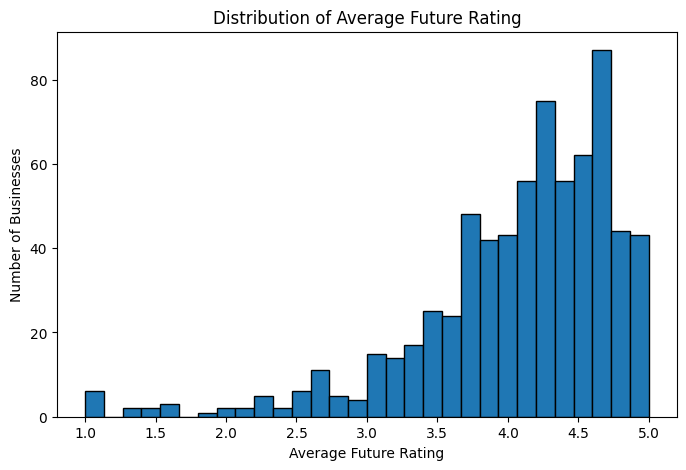

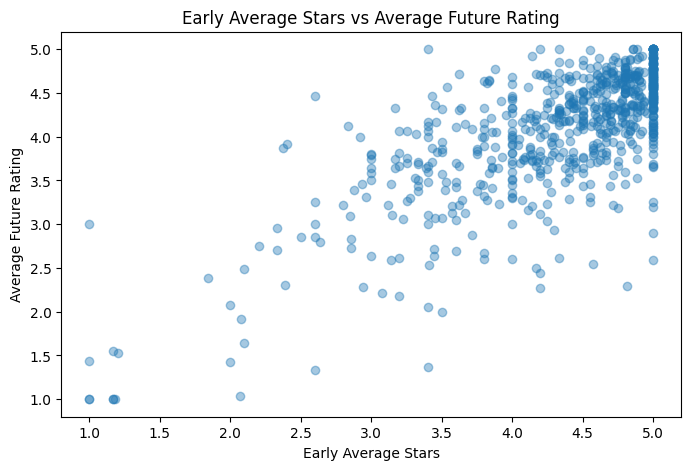

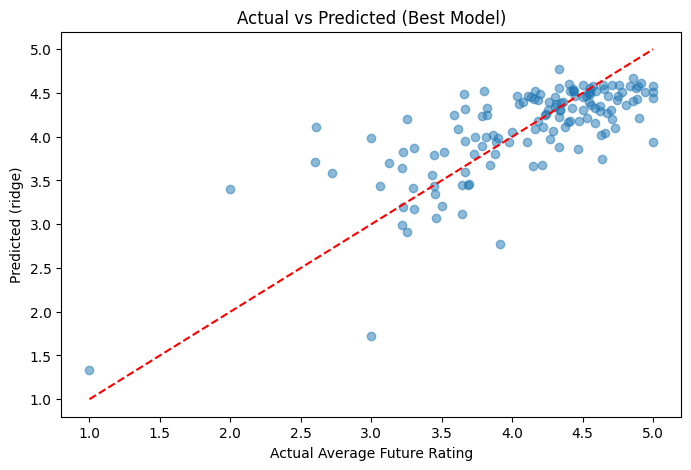

Best model: ridge
model            ridge
mae           0.323268
r2            0.535212
n_train            561
n_test             141
n_features          14
Name: 0, dtype: object


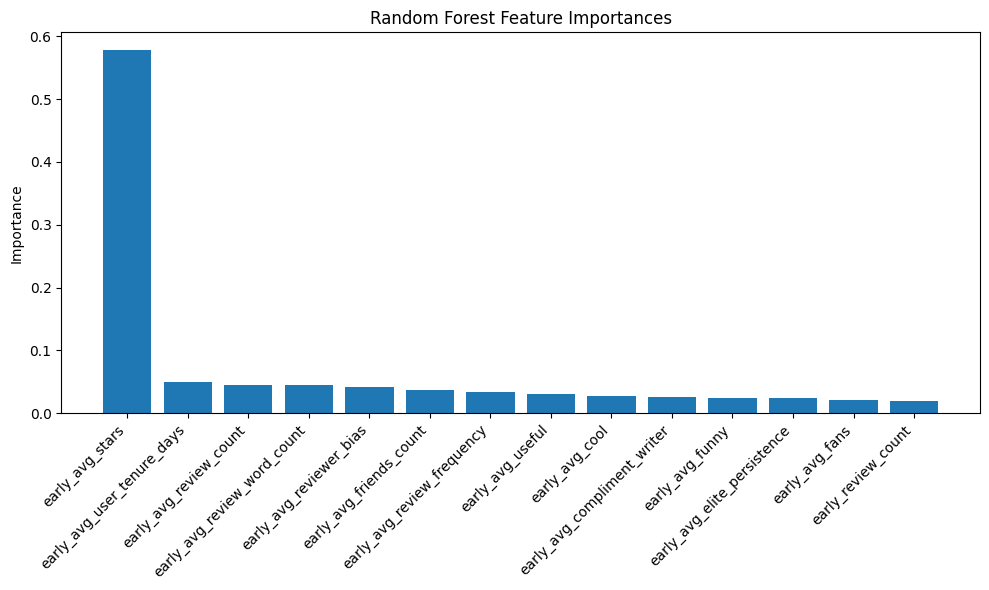

Top correlations with average_future_rating:


,feature,corr
0,early_avg_stars,0.728076
1,early_avg_reviewer_bias,0.597283
2,early_avg_review_word_count,-0.161121
3,early_avg_cool,0.101293
4,early_avg_friends_count,0.099671
5,early_avg_elite_persistence,0.088998
6,early_avg_user_tenure_days,0.087051
7,early_avg_fans,0.080178
8,early_avg_compliment_writer,0.070927
9,early_avg_review_count,0.043372


,business_id,early_avg_stars,early_avg_useful,early_avg_funny,early_avg_cool,early_avg_review_count,early_avg_fans,early_avg_friends_count,early_avg_compliment_writer,early_avg_reviewer_bias,early_avg_user_tenure_days,early_avg_elite_persistence,early_avg_review_word_count,early_avg_review_frequency,early_review_count,average_future_rating
1,-1YvpVvnnLrTZ0zjtUYPXA,2.923077,4.538462,0.307692,0.615385,50.846154,2.461538,105.230769,1.692308,-0.883846,1912.461538,1.461538,125.769231,21.384615,13,4.000000
8,-2wh7NTLkWEgsrLJvilnFQ,4.666667,0.833333,0.000000,0.333333,7.000000,0.000000,8.500000,0.000000,0.696667,2011.333333,0.000000,52.666667,4.000000,6,4.400000
9,-3-6BB10tIWNKGEF0Es2BA,3.846154,3.000000,0.538462,1.153846,59.538462,5.153846,73.769231,2.461538,0.253846,1876.769231,0.846154,108.153846,37.384615,13,4.212598
11,-4N4YEobjG89VQsEgqZshg,4.571429,1.857143,0.285714,0.714286,146.714286,23.000000,195.285714,21.571429,0.574286,2458.142857,2.571429,174.571429,39.714286,7,3.900000
14,-6qt8a52bBwMogqwZsooOA,5.000000,0.600000,0.000000,0.600000,29.400000,0.600000,89.200000,0.000000,0.682000,2032.200000,0.000000,53.000000,1.000000,5,4.541667


In [12]:
pipeline_output = run_prediction_pipeline(
    processed_dir=PROCESSED_DIR,
    cohort_year=COHORT_YEAR,
    early_window_days=EARLY_WINDOW_DAYS,
    future_window_end_day=FUTURE_WINDOW_END_DAY,
    period=PERIOD,
    min_early_reviews=MIN_EARLY_REVIEWS,
    min_future_reviews=MIN_FUTURE_REVIEWS,
    feature_file=FEATURE_FILE,
)

model_df = pipeline_output["model_df"]
feature_cols = pipeline_output["feature_cols"]
target_col = pipeline_output["target_col"]

print("Model dataset shape:", model_df.shape)
print("Target column:", target_col)
print("Number of features:", len(feature_cols))
print("First 10 feature columns:", feature_cols[:10])
print("Sanity report:", pipeline_output["sanity_report"])
print("Regression summary:")
print(pipeline_output["regression_report"]["results_df"])

output_dir = PROCESSED_DIR / "modeling_tables"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"business_level_{EARLY_WINDOW_DAYS}D_{FUTURE_WINDOW_END_DAY}D_{PERIOD}.csv"
model_df.to_csv(output_path, index=False, float_format="%.4f")
print("Saved modeling table to:", output_path.resolve())

results_package = generate_results_package(
    pipeline_output=pipeline_output,
    target_col=target_col,
    top_n_correlations=15,
    show_plots=True,
)

print("Top correlations with average_future_rating:")
display(results_package["correlation_table"])

model_df.head()

In [3]:
# Exploratory Tables and Graphs
# Summary stats, head, and missing values
import pandas as pd

print("Model dataset shape:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())

print("\nSummary statistics:")
print(model_df.describe())

print("\nMissing values per column:")
print(model_df.isnull().sum())

print("\nFirst 5 rows:")
model_df.head()

Model dataset shape: (702, 16)

Columns:
['business_id', 'early_avg_stars', 'early_avg_useful', 'early_avg_funny', 'early_avg_cool', 'early_avg_review_count', 'early_avg_fans', 'early_avg_friends_count', 'early_avg_compliment_writer', 'early_avg_reviewer_bias', 'early_avg_user_tenure_days', 'early_avg_elite_persistence', 'early_avg_review_word_count', 'early_avg_review_frequency', 'early_review_count', 'average_future_rating']

Summary statistics:
       early_avg_stars  early_avg_useful  early_avg_funny  early_avg_cool  \
count       702.000000        702.000000       702.000000      702.000000   
mean          4.317111          1.881369         0.445866        1.062846   
std           0.749054          2.292989         1.065446        2.062878   
min           1.000000          0.000000         0.000000        0.000000   
25%           4.000000          0.717532         0.000000        0.200000   
50%           4.555556          1.333333         0.200000        0.500000   
75%      

,business_id,early_avg_stars,early_avg_useful,early_avg_funny,early_avg_cool,early_avg_review_count,early_avg_fans,early_avg_friends_count,early_avg_compliment_writer,early_avg_reviewer_bias,early_avg_user_tenure_days,early_avg_elite_persistence,early_avg_review_word_count,early_avg_review_frequency,early_review_count,average_future_rating
1,-1YvpVvnnLrTZ0zjtUYPXA,2.923077,4.538462,0.307692,0.615385,50.846154,2.461538,105.230769,1.692308,-0.883846,1912.461538,1.461538,125.769231,21.384615,13,4.000000
8,-2wh7NTLkWEgsrLJvilnFQ,4.666667,0.833333,0.000000,0.333333,7.000000,0.000000,8.500000,0.000000,0.696667,2011.333333,0.000000,52.666667,4.000000,6,4.400000
9,-3-6BB10tIWNKGEF0Es2BA,3.846154,3.000000,0.538462,1.153846,59.538462,5.153846,73.769231,2.461538,0.253846,1876.769231,0.846154,108.153846,37.384615,13,4.212598
11,-4N4YEobjG89VQsEgqZshg,4.571429,1.857143,0.285714,0.714286,146.714286,23.000000,195.285714,21.571429,0.574286,2458.142857,2.571429,174.571429,39.714286,7,3.900000
14,-6qt8a52bBwMogqwZsooOA,5.000000,0.600000,0.000000,0.600000,29.400000,0.600000,89.200000,0.000000,0.682000,2032.200000,0.000000,53.000000,1.000000,5,4.541667


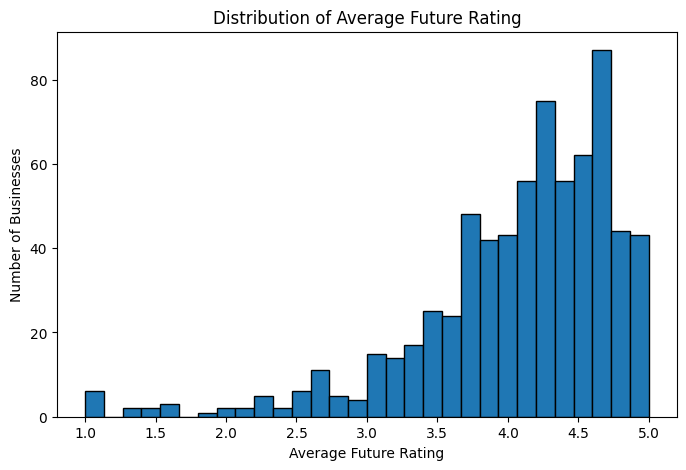

In [4]:
# Target distribution: average_future_rating
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(model_df["average_future_rating"], bins=30, edgecolor="black")
plt.xlabel("Average Future Rating")
plt.ylabel("Number of Businesses")
plt.title("Distribution of Average Future Rating")
plt.show()

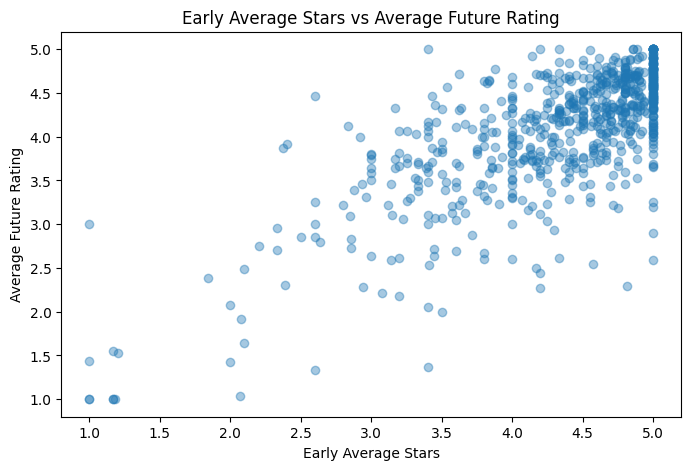

In [5]:
# Relationship: early_avg_stars vs average_future_rating
plt.figure(figsize=(8, 5))
plt.scatter(model_df["early_avg_stars"], model_df["average_future_rating"], alpha=0.4)
plt.xlabel("Early Average Stars")
plt.ylabel("Average Future Rating")
plt.title("Early Average Stars vs Average Future Rating")
plt.show()

In [6]:
# Correlation with target: top features
numeric_cols = model_df.select_dtypes(include="number").columns.tolist()
if "average_future_rating" in numeric_cols:
    corr_series = model_df[numeric_cols].corr()["average_future_rating"].drop("average_future_rating")
    corr_top = corr_series.abs().sort_values(ascending=False).head(15)
    print("Top correlations with average_future_rating (by absolute value):")
    display(pd.DataFrame({"feature": corr_top.index, "corr": corr_top.values}))
else:
    print("average_future_rating not in numeric columns; skipping correlation summary.")

Top correlations with average_future_rating (by absolute value):


,feature,corr
0,early_avg_stars,0.728076
1,early_avg_reviewer_bias,0.597283
2,early_avg_review_word_count,0.161121
3,early_avg_cool,0.101293
4,early_avg_friends_count,0.099671
5,early_avg_elite_persistence,0.088998
6,early_avg_user_tenure_days,0.087051
7,early_avg_fans,0.080178
8,early_avg_compliment_writer,0.070927
9,early_avg_review_count,0.043372


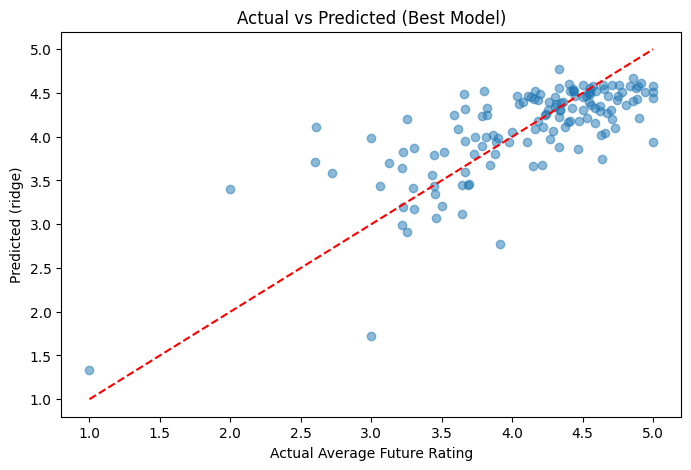

Best model: ridge
model            ridge
mae           0.323268
r2            0.535212
n_train            561
n_test             141
n_features          14
Name: 0, dtype: object


In [7]:
# Predicted vs Actual: best-performing model from regression_report
import numpy as np

results_df = pipeline_output["regression_report"]["results_df"]
predictions_df = pipeline_output["regression_report"]["predictions_df"].copy()

# Pick the best model by MAE (exclude baseline if desired)
ranked = results_df.sort_values(["mae", "r2"], ascending=[True, False])
# If you want to skip baseline, filter it out here
best_row = ranked.iloc[0]
best_model = best_row["model"]

pred_col = f"pred_{best_model}" if best_model != "baseline_mean" else "pred_baseline_mean"

y_true = predictions_df["average_future_rating"].values
y_pred = predictions_df[pred_col].values

plt.figure(figsize=(8, 5))
plt.scatter(y_true, y_pred, alpha=0.5)
min_val = float(min(y_true.min(), y_pred.min()))
max_val = float(max(y_true.max(), y_pred.max()))
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red")
plt.xlabel("Actual Average Future Rating")
plt.ylabel(f"Predicted ({best_model})")
plt.title("Actual vs Predicted (Best Model)")
plt.show()

print("Best model:", best_model)
print(best_row)

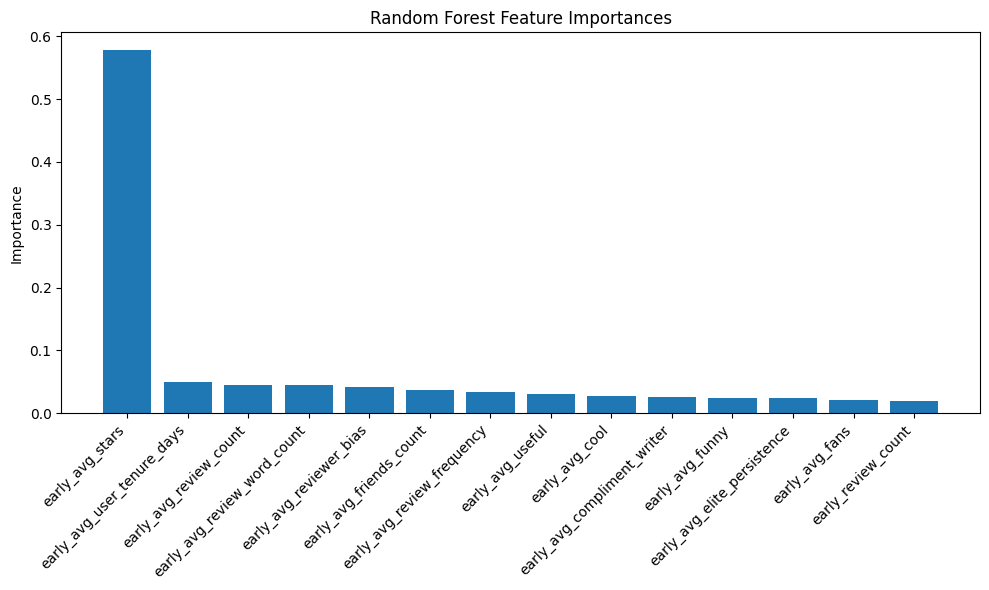

In [8]:
# Random Forest feature importances (if available)
rf_model = pipeline_output["regression_report"]["fitted_models"].get("random_forest")
if rf_model is not None and hasattr(rf_model, "feature_importances_"):
    importances = rf_model.feature_importances_
    order = np.argsort(importances)[::-1]
    feat = np.array(feature_cols)[order]
    imp = importances[order]

    plt.figure(figsize=(10, 6))
    plt.bar(range(len(imp)), imp, tick_label=feat)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Importance")
    plt.title("Random Forest Feature Importances")
    plt.tight_layout()
    plt.show()
else:
    print("Random Forest model not available or missing feature_importances_ attribute.")